<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/08_Global_Fusion_Models_7d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 08 — Global MLP–GRU and MLP–LSTM Fusion Models

This notebook tests two **joint latent-feature fusion models** using the pooled 7-day BTC, ETH, SOL and XRP dataset:

1. **MLP–GRU Fusion**
2. **MLP–LSTM Fusion**

These are not prediction averages. Each model jointly learns:

- a nonlinear fixed-lag representation through the MLP branch;
- a sequential representation through the GRU or LSTM branch;
- an asset-aware forecast from the combined latent representations.

The validation set is used for model comparison. The test set remains untouched.


## 1. Imports and reproducibility


In [1]:
from google.colab import drive
from pathlib import Path

import json
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Flatten,
    Dense,
    Dropout,
    GRU,
    LSTM,
    Concatenate,
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Mount Drive and configure paths


In [2]:
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:
shared_project_dir = Path(
    "/content/drive/MyDrive/Quant Research"
)

artifacts_dir = (
    shared_project_dir
    / "data"
    / "model_ready"
    / "GLOBAL_4_ASSETS"
    / "lookback_7d"
)

previous_results_dir = (
    shared_project_dir
    / "results"
    / "GLOBAL_4_ASSETS"
    / "lookback_7d"
)

fusion_results_dir = (
    shared_project_dir
    / "results"
    / "GLOBAL_4_ASSETS"
    / "lookback_7d"
    / "FUSION_MODELS"
)

fusion_models_dir = (
    shared_project_dir
    / "models"
    / "GLOBAL_4_ASSETS"
    / "lookback_7d"
    / "FUSION_MODELS"
)

fusion_results_dir.mkdir(
    parents=True,
    exist_ok=True
)

fusion_models_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("Artifacts:", artifacts_dir)
print("Fusion results:", fusion_results_dir)
print("Fusion models:", fusion_models_dir)


Artifacts: /content/drive/MyDrive/Quant Research/data/model_ready/GLOBAL_4_ASSETS/lookback_7d
Fusion results: /content/drive/MyDrive/Quant Research/results/GLOBAL_4_ASSETS/lookback_7d/FUSION_MODELS
Fusion models: /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/FUSION_MODELS


## 3. Load the saved pooled 7-day dataset


In [4]:
required_artifact_paths = {
    "X_train": (
        artifacts_dir
        / "X_train_scaled.npy"
    ),
    "X_val": (
        artifacts_dir
        / "X_val_scaled.npy"
    ),
    "A_train": (
        artifacts_dir
        / "asset_train_one_hot.npy"
    ),
    "A_val": (
        artifacts_dir
        / "asset_val_one_hot.npy"
    ),
    "y_train_scaled": (
        artifacts_dir
        / "y_train_scaled.npy"
    ),
    "y_val_scaled": (
        artifacts_dir
        / "y_val_scaled.npy"
    ),
    "validation_metadata": (
        artifacts_dir
        / "validation_metadata.parquet"
    ),
    "target_scalers": (
        artifacts_dir
        / "target_scalers_by_asset.joblib"
    ),
    "configuration": (
        artifacts_dir
        / "experiment_configuration.json"
    ),
}

missing_artifacts = [
    str(path)
    for path in required_artifact_paths.values()
    if not path.exists()
]

if missing_artifacts:
    raise FileNotFoundError(
        "Missing pooled-data artifacts:\n"
        + "\n".join(missing_artifacts)
    )

X_train = np.load(
    required_artifact_paths["X_train"]
)

X_val = np.load(
    required_artifact_paths["X_val"]
)

A_train = np.load(
    required_artifact_paths["A_train"]
)

A_val = np.load(
    required_artifact_paths["A_val"]
)

y_train_scaled = np.load(
    required_artifact_paths[
        "y_train_scaled"
    ]
)

y_val_scaled = np.load(
    required_artifact_paths[
        "y_val_scaled"
    ]
)

validation_metadata = pd.read_parquet(
    required_artifact_paths[
        "validation_metadata"
    ]
)

target_scalers = joblib.load(
    required_artifact_paths[
        "target_scalers"
    ]
)

with open(
    required_artifact_paths[
        "configuration"
    ],
    "r",
    encoding="utf-8"
) as file:
    configuration = json.load(file)

ASSETS = configuration["assets"]
LOOKBACK_DAYS = int(
    configuration["lookback_days"]
)
FEATURE_COLUMNS = (
    configuration["feature_columns"]
)

print("Assets:", ASSETS)
print("Lookback:", LOOKBACK_DAYS)
print("X_train:", X_train.shape)
print("A_train:", A_train.shape)
print("y_train:", y_train_scaled.shape)
print("X_val:", X_val.shape)
print("A_val:", A_val.shape)
print("y_val:", y_val_scaled.shape)


Assets: ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT']
Lookback: 7
X_train: (5912, 7, 7)
A_train: (5912, 4)
y_train: (5912,)
X_val: (1460, 7, 7)
A_val: (1460, 4)
y_val: (1460,)


## 4. Dataset integrity checks


In [5]:
assert X_train.ndim == 3
assert X_val.ndim == 3

assert X_train.shape[1] == LOOKBACK_DAYS
assert X_val.shape[1] == LOOKBACK_DAYS

assert X_train.shape[2] == len(
    FEATURE_COLUMNS
)

assert X_val.shape[2] == len(
    FEATURE_COLUMNS
)

assert len(X_train) == len(
    A_train
) == len(y_train_scaled)

assert len(X_val) == len(
    A_val
) == len(y_val_scaled)

assert len(X_val) == len(
    validation_metadata
)

assert A_train.shape[1] == len(ASSETS)
assert A_val.shape[1] == len(ASSETS)

assert np.isfinite(X_train).all()
assert np.isfinite(X_val).all()
assert np.isfinite(A_train).all()
assert np.isfinite(A_val).all()
assert np.isfinite(y_train_scaled).all()
assert np.isfinite(y_val_scaled).all()

assert set(
    validation_metadata["symbol"].unique()
) == set(ASSETS)

assert (
    validation_metadata[
        "target_date"
    ]
    - validation_metadata[
        "sequence_end_date"
    ]
).eq(
    pd.Timedelta(days=1)
).all()

display(
    validation_metadata[
        "symbol"
    ].value_counts()
)

print(
    "All pooled validation-data checks passed."
)


,count
symbol,
BTCUSDT,365
ETHUSDT,365
SOLUSDT,365
XRPUSDT,365


All pooled validation-data checks passed.


## 5. Evaluation helpers


In [6]:
def mean_absolute_error(
    y_true,
    y_pred
):
    return np.mean(
        np.abs(
            np.asarray(y_true)
            - np.asarray(y_pred)
        )
    )


def root_mean_squared_error(
    y_true,
    y_pred
):
    return np.sqrt(
        np.mean(
            (
                np.asarray(y_true)
                - np.asarray(y_pred)
            ) ** 2
        )
    )


def qlike(
    y_true,
    y_pred,
    epsilon=1e-12
):
    y_true = np.maximum(
        np.asarray(y_true),
        epsilon
    )

    y_pred = np.maximum(
        np.asarray(y_pred),
        epsilon
    )

    ratio = y_true / y_pred

    return np.mean(
        ratio
        - np.log(ratio)
        - 1
    )


def inverse_target_predictions(
    pred_scaled,
    metadata
):
    pred_log_rv = np.empty(
        len(pred_scaled),
        dtype=np.float64
    )

    for symbol in ASSETS:
        asset_mask = (
            metadata["symbol"]
            .eq(symbol)
            .to_numpy()
        )

        pred_log_rv[
            asset_mask
        ] = (
            target_scalers[symbol]
            .inverse_transform(
                pred_scaled[
                    asset_mask
                ].reshape(-1, 1)
            )
            .reshape(-1)
        )

    pred_rv = np.exp(
        pred_log_rv
    )

    return pred_log_rv, pred_rv


def evaluate_by_asset(
    model_name,
    pred_rv,
    metadata
):
    rows = []

    for symbol in ASSETS:
        asset_mask = (
            metadata["symbol"]
            .eq(symbol)
            .to_numpy()
        )

        actual_rv = metadata.loc[
            asset_mask,
            "actual_rv"
        ].to_numpy()

        asset_pred_rv = pred_rv[
            asset_mask
        ]

        rows.append({
            "asset": symbol,
            "model": model_name,
            "n_observations": int(
                asset_mask.sum()
            ),
            "mae": mean_absolute_error(
                actual_rv,
                asset_pred_rv
            ),
            "rmse": (
                root_mean_squared_error(
                    actual_rv,
                    asset_pred_rv
                )
            ),
            "qlike": qlike(
                actual_rv,
                asset_pred_rv
            ),
        })

    actual_all = metadata[
        "actual_rv"
    ].to_numpy()

    rows.append({
        "asset": "ALL_ASSETS",
        "model": model_name,
        "n_observations": len(metadata),
        "mae": mean_absolute_error(
            actual_all,
            pred_rv
        ),
        "rmse": (
            root_mean_squared_error(
                actual_all,
                pred_rv
            )
        ),
        "qlike": qlike(
            actual_all,
            pred_rv
        ),
    })

    return pd.DataFrame(rows)


## 6. Fusion architectures

Both branches receive the same 7-day feature sequence.

### MLP–GRU
- MLP branch: nonlinear fixed-lag interactions
- GRU branch: ordered temporal dynamics
- Fusion head: jointly learns from both latent representations and asset identity

### MLP–LSTM
- MLP branch: nonlinear fixed-lag interactions
- LSTM branch: gated temporal memory
- Fusion head: jointly learns from both latent representations and asset identity


In [7]:
def build_mlp_branch(
    sequence_input
):
    mlp_embedding = Flatten(
        name="mlp_flatten"
    )(sequence_input)

    mlp_embedding = Dense(
        64,
        activation="relu",
        name="mlp_dense_64"
    )(mlp_embedding)

    mlp_embedding = Dropout(
        0.20,
        name="mlp_dropout"
    )(mlp_embedding)

    mlp_embedding = Dense(
        32,
        activation="relu",
        name="mlp_dense_32"
    )(mlp_embedding)

    mlp_embedding = Dense(
        16,
        activation="relu",
        name="mlp_embedding"
    )(mlp_embedding)

    return mlp_embedding


def compile_fusion_model(
    sequence_input,
    asset_input,
    mlp_embedding,
    recurrent_embedding,
    model_name
):
    fused = Concatenate(
        name="latent_feature_fusion"
    )([
        mlp_embedding,
        recurrent_embedding,
        asset_input,
    ])

    fused = Dense(
        24,
        activation="relu",
        name="fusion_dense_24"
    )(fused)

    fused = Dropout(
        0.10,
        name="fusion_dropout"
    )(fused)

    fused = Dense(
        12,
        activation="relu",
        name="fusion_dense_12"
    )(fused)

    output = Dense(
        1,
        activation="linear",
        name="predicted_scaled_log_rv"
    )(fused)

    model = Model(
        inputs=[
            sequence_input,
            asset_input
        ],
        outputs=output,
        name=model_name
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )

    return model


def build_mlp_gru_fusion(
    lookback_days,
    n_features,
    n_assets
):
    sequence_input = Input(
        shape=(
            lookback_days,
            n_features
        ),
        name="sequence_input"
    )

    asset_input = Input(
        shape=(n_assets,),
        name="asset_input"
    )

    mlp_embedding = build_mlp_branch(
        sequence_input
    )

    recurrent_embedding = GRU(
        32,
        activation="tanh",
        recurrent_activation="sigmoid",
        dropout=0.0,
        recurrent_dropout=0.0,
        return_sequences=False,
        name="gru_encoder"
    )(sequence_input)

    recurrent_embedding = Dropout(
        0.20,
        name="gru_dropout"
    )(recurrent_embedding)

    recurrent_embedding = Dense(
        16,
        activation="relu",
        name="gru_embedding"
    )(recurrent_embedding)

    return compile_fusion_model(
        sequence_input=sequence_input,
        asset_input=asset_input,
        mlp_embedding=mlp_embedding,
        recurrent_embedding=(
            recurrent_embedding
        ),
        model_name="global_mlp_gru_fusion"
    )


def build_mlp_lstm_fusion(
    lookback_days,
    n_features,
    n_assets
):
    sequence_input = Input(
        shape=(
            lookback_days,
            n_features
        ),
        name="sequence_input"
    )

    asset_input = Input(
        shape=(n_assets,),
        name="asset_input"
    )

    mlp_embedding = build_mlp_branch(
        sequence_input
    )

    recurrent_embedding = LSTM(
        32,
        activation="tanh",
        recurrent_activation="sigmoid",
        dropout=0.0,
        recurrent_dropout=0.0,
        return_sequences=False,
        name="lstm_encoder"
    )(sequence_input)

    recurrent_embedding = Dropout(
        0.20,
        name="lstm_dropout"
    )(recurrent_embedding)

    recurrent_embedding = Dense(
        16,
        activation="relu",
        name="lstm_embedding"
    )(recurrent_embedding)

    return compile_fusion_model(
        sequence_input=sequence_input,
        asset_input=asset_input,
        mlp_embedding=mlp_embedding,
        recurrent_embedding=(
            recurrent_embedding
        ),
        model_name=(
            "global_mlp_lstm_fusion"
        )
    )


## 7. Train both fusion models


In [8]:
FUSION_BUILDERS = {
    "MLP-GRU": build_mlp_gru_fusion,
    "MLP-LSTM": build_mlp_lstm_fusion,
}

fusion_metric_frames = []
fusion_prediction_frames = []
fusion_histories = {}
fusion_parameter_rows = []

for fusion_name, builder in (
    FUSION_BUILDERS.items()
):
    print(
        "\n" + "=" * 75
    )
    print(
        f"Training {fusion_name} Fusion"
    )
    print(
        "=" * 75
    )

    tf.keras.backend.clear_session()

    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = builder(
        lookback_days=X_train.shape[1],
        n_features=X_train.shape[2],
        n_assets=A_train.shape[1],
    )

    model.summary()

    model_output_dir = (
        fusion_models_dir
        / fusion_name.replace("-", "_")
    )

    result_output_dir = (
        fusion_results_dir
        / fusion_name.replace("-", "_")
    )

    model_output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    result_output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    best_model_path = (
        model_output_dir
        / (
            "best_"
            + fusion_name.lower()
            .replace("-", "_")
            + "_fusion.keras"
        )
    )

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            min_delta=1e-4,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1,
        ),
        ModelCheckpoint(
            filepath=best_model_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
    ]

    history = model.fit(
        [X_train, A_train],
        y_train_scaled,
        validation_data=(
            [X_val, A_val],
            y_val_scaled,
        ),
        epochs=200,
        batch_size=32,
        shuffle=False,
        callbacks=callbacks,
        verbose=1,
    )

    pred_scaled = (
        model.predict(
            [X_val, A_val],
            batch_size=32,
            verbose=0,
        )
        .reshape(-1)
    )

    pred_log_rv, pred_rv = (
        inverse_target_predictions(
            pred_scaled=pred_scaled,
            metadata=validation_metadata,
        )
    )

    model_label = (
        "Fusion-"
        + fusion_name
        + "-7d"
    )

    metrics_df = evaluate_by_asset(
        model_name=model_label,
        pred_rv=pred_rv,
        metadata=validation_metadata,
    )

    prediction_df = (
        validation_metadata.copy()
    )

    prediction_df[
        "model"
    ] = model_label

    prediction_df[
        "pred_scaled_log_rv"
    ] = pred_scaled

    prediction_df[
        "pred_log_rv"
    ] = pred_log_rv

    prediction_df[
        "pred_rv"
    ] = pred_rv

    history_df = pd.DataFrame(
        history.history
    )

    history_df["epoch"] = (
        np.arange(
            len(history_df)
        )
        + 1
    )

    metrics_df.to_csv(
        result_output_dir
        / "validation_metrics_by_asset.csv",
        index=False
    )

    prediction_df.to_parquet(
        result_output_dir
        / "validation_predictions.parquet",
        index=False
    )

    history_df.to_csv(
        result_output_dir
        / "training_history.csv",
        index=False
    )

    model.save(
        model_output_dir
        / (
            "final_"
            + fusion_name.lower()
            .replace("-", "_")
            + "_fusion.keras"
        )
    )

    fusion_metric_frames.append(
        metrics_df
    )

    fusion_prediction_frames.append(
        prediction_df
    )

    fusion_histories[
        fusion_name
    ] = history_df

    fusion_parameter_rows.append({
        "model": model_label,
        "trainable_parameters": (
            model.count_params()
        ),
        "epochs_run": len(
            history_df
        ),
        "best_validation_loss": (
            history_df[
                "val_loss"
            ].min()
        ),
        "best_epoch": int(
            history_df.loc[
                history_df[
                    "val_loss"
                ].idxmin(),
                "epoch"
            ]
        ),
    })

    display(
        metrics_df.sort_values(
            "qlike"
        )
    )



Training MLP-GRU Fusion


Model: "global_mlp_gru_fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_flatten         │ (None, 49)        │          0 │ sequence_input[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_64        │ (None, 64)        │      3,200 │ mlp_flatten[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dropout         │ (None, 64)        │          0 │ mlp_dense_64[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_encoder (GRU)   │ (None, 32)        │      3,936 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_32        │ (None, 32)        │      2,080 │ mlp_dropout[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_dropout         │ (None, 32)        │          0 │ gru_encoder[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_embedding       │ (None, 16)        │        528 │ mlp_dense_32[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_embedding       │ (None, 16)        │        528 │ gru_dropout[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ asset_input         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_feature_fus… │ (None, 36)        │          0 │ mlp_embedding[0]… │
│ (Concatenate)       │                   │            │ gru_embedding[0]… │
│                     │                   │            │ asset_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_24     │ (None, 24)        │        888 │ latent_feature_f… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout      │ (None, 24)        │          0 │ fusion_dense_24[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_12     │ (None, 12)        │        300 │ fusion_dropout[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predicted_scaled_l… │ (None, 1)         │         13 │ fusion_dense_12[… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,473 (44.82 KB)

 Trainable params: 11,473 (44.82 KB)

...

 Total params: 12,657 (49.44 KB)

 Trainable params: 12,657 (49.44 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
181/185 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8808 - mae: 0.7181
Epoch 1: val_loss improved from None to 0.49313, saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/FUSION_MODELS/MLP_LSTM/best_mlp_lstm_fusion.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/FUSION_MODELS/MLP_LSTM/best_mlp_lstm_fusion.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.6931 - mae: 0.6327 - val_loss: 0.4931 - val_mae: 0.5527 - learning_rate: 0.0010
Epoch 2/200
179/185 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5400 - mae: 0.5509
Epoch 2: val_loss improved from 0.49313 to 0.44236, saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/FUSION_MODELS/MLP_LSTM/best_mlp_lstm_fusion.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/FUSION_MODELS/MLP_LSTM/best_mlp_lstm_fusion.keras
185/185 

,asset,model,n_observations,mae,rmse,qlike
2,SOLUSDT,Fusion-MLP-LSTM-7d,365,0.001145,0.002509,0.196284
0,BTCUSDT,Fusion-MLP-LSTM-7d,365,0.000368,0.000826,0.254830
1,ETHUSDT,Fusion-MLP-LSTM-7d,365,0.000775,0.001774,0.261141
4,ALL_ASSETS,Fusion-MLP-LSTM-7d,1460,0.000983,0.002498,0.284152
3,XRPUSDT,Fusion-MLP-LSTM-7d,365,0.001645,0.003852,0.424352


## 8. Training summaries


,model,trainable_parameters,epochs_run,best_validation_loss,best_epoch
0,Fusion-MLP-GRU-7d,11473,50,0.415011,35
1,Fusion-MLP-LSTM-7d,12657,51,0.412683,37


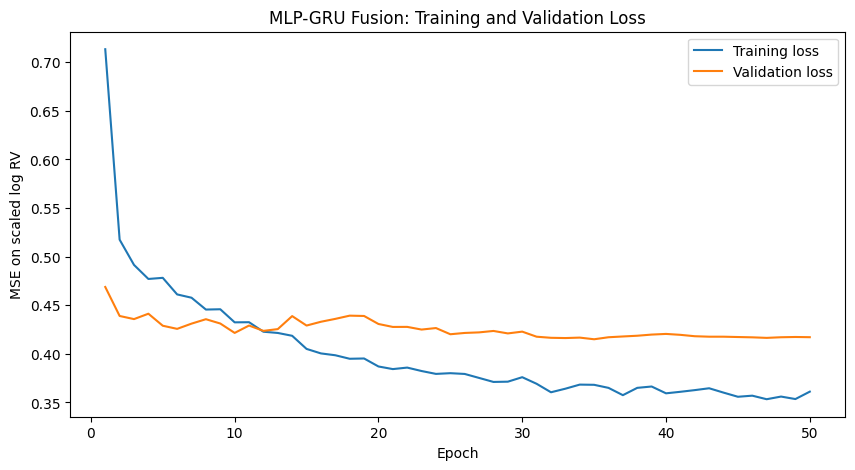

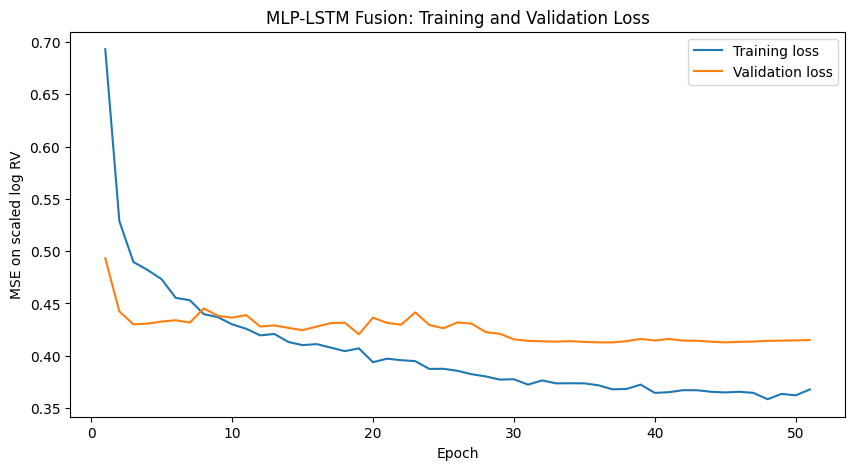

In [9]:
fusion_training_summary_df = pd.DataFrame(
    fusion_parameter_rows
)

fusion_training_summary_df.to_csv(
    fusion_results_dir
    / "fusion_training_summary.csv",
    index=False
)

display(
    fusion_training_summary_df.style.format({
        "best_validation_loss": "{:.6f}",
    })
)

for fusion_name, history_df in (
    fusion_histories.items()
):
    plt.figure(
        figsize=(10, 5)
    )

    plt.plot(
        history_df["epoch"],
        history_df["loss"],
        label="Training loss"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        label="Validation loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel(
        "MSE on scaled log RV"
    )
    plt.title(
        f"{fusion_name} Fusion: "
        "Training and Validation Loss"
    )
    plt.legend()
    plt.show()


## 9. Compare fusion models with all prior global models and baselines

The previous global notebook saved the baseline and standalone-model comparison. This section appends the two fusion models and reranks every model within each asset.


In [10]:
previous_comparison_path = (
    previous_results_dir
    / (
        "final_validation_"
        "comparison_by_asset.csv"
    )
)

if not previous_comparison_path.exists():
    raise FileNotFoundError(
        "Previous global comparison file "
        f"not found:\n{previous_comparison_path}"
    )

previous_comparison_df = pd.read_csv(
    previous_comparison_path
)

required_metric_columns = {
    "asset",
    "model",
    "n_observations",
    "mae",
    "rmse",
    "qlike",
}

missing_previous_columns = (
    required_metric_columns
    - set(previous_comparison_df.columns)
)

if missing_previous_columns:
    raise ValueError(
        "Previous comparison file is "
        "missing columns: "
        f"{missing_previous_columns}"
    )

previous_comparison_df = (
    previous_comparison_df[
        [
            "asset",
            "model",
            "n_observations",
            "mae",
            "rmse",
            "qlike",
        ]
    ]
)

fusion_metrics_df = pd.concat(
    fusion_metric_frames,
    ignore_index=True
)

final_comparison_df = pd.concat(
    [
        previous_comparison_df,
        fusion_metrics_df,
    ],
    ignore_index=True
)

final_comparison_df = (
    final_comparison_df
    .drop_duplicates(
        subset=[
            "asset",
            "model"
        ],
        keep="last"
    )
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)

final_comparison_df[
    "qlike_rank_within_asset"
] = (
    final_comparison_df
    .groupby("asset")["qlike"]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)

final_comparison_df = (
    final_comparison_df[
        [
            "asset",
            "qlike_rank_within_asset",
            "model",
            "n_observations",
            "mae",
            "rmse",
            "qlike",
        ]
    ]
)

final_comparison_df.to_csv(
    fusion_results_dir
    / (
        "final_validation_comparison_"
        "with_fusion_models.csv"
    ),
    index=False
)

display(
    final_comparison_df.style.format({
        "mae": "{:.8f}",
        "rmse": "{:.8f}",
        "qlike": "{:.6f}",
    })
)


,asset,qlike_rank_within_asset,model,n_observations,mae,rmse,qlike
0,ALL_ASSETS,1,Global-MLP-7d,1460,0.00097828,0.00251826,0.272339
1,ALL_ASSETS,2,Global-GRU-7d,1460,0.00095687,0.00244102,0.282636
2,ALL_ASSETS,3,Fusion-MLP-LSTM-7d,1460,0.00098312,0.00249810,0.284152
3,ALL_ASSETS,4,Fusion-MLP-GRU-7d,1460,0.00099272,0.00251250,0.284842
4,ALL_ASSETS,5,Global-LSTM-7d,1460,0.00098232,0.00251217,0.287813
5,BTCUSDT,1,Global-MLP-7d,365,0.00037331,0.00081176,0.247444
6,BTCUSDT,2,Fusion-MLP-LSTM-7d,365,0.00036757,0.00082619,0.254830
7,BTCUSDT,3,Global-GRU-7d,365,0.00036146,0.00080757,0.265197
8,BTCUSDT,4,Global-LSTM-7d,365,0.00036349,0.00082216,0.270049
9,BTCUSDT,5,Fusion-MLP-GRU-7d,365,0.00038626,0.00087052,0.276312


## 10. QLIKE pivot and best model by asset


In [11]:
qlike_pivot_df = (
    final_comparison_df
    .pivot(
        index="model",
        columns="asset",
        values="qlike",
    )
)

qlike_pivot_df.to_csv(
    fusion_results_dir
    / "qlike_pivot_with_fusion_models.csv"
)

display(
    qlike_pivot_df.style.format(
        "{:.6f}"
    )
)

best_model_by_asset_df = (
    final_comparison_df
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .groupby(
        "asset",
        as_index=False
    )
    .first()
)

best_model_by_asset_df.to_csv(
    fusion_results_dir
    / "best_validation_model_by_asset.csv",
    index=False
)

display(
    best_model_by_asset_df.style.format({
        "mae": "{:.8f}",
        "rmse": "{:.8f}",
        "qlike": "{:.6f}",
    })
)


asset,ALL_ASSETS,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT
model,,,,,
30-Day Mean RV,nan,0.399752,0.407022,0.342676,0.625613
7-Day Mean RV,nan,0.343857,0.368690,0.276899,0.469705
Fusion-MLP-GRU-7d,0.284842,0.276312,0.262096,0.184368,0.416591
Fusion-MLP-LSTM-7d,0.284152,0.254830,0.261141,0.196284,0.424352
Global-GRU-7d,0.282636,0.265197,0.272646,0.193730,0.398971
Global-LSTM-7d,0.287813,0.270049,0.256810,0.192756,0.431636
Global-MLP-7d,0.272339,0.247444,0.244669,0.199853,0.397392
Persistence,nan,0.464700,0.415368,0.325781,0.554703


,asset,qlike_rank_within_asset,model,n_observations,mae,rmse,qlike
0,ALL_ASSETS,1,Global-MLP-7d,1460,0.00097828,0.00251826,0.272339
1,BTCUSDT,1,Global-MLP-7d,365,0.00037331,0.00081176,0.247444
2,ETHUSDT,1,Global-MLP-7d,365,0.00075761,0.00173944,0.244669
3,SOLUSDT,1,Fusion-MLP-GRU-7d,365,0.00110749,0.00246050,0.184368
4,XRPUSDT,1,Global-MLP-7d,365,0.00165550,0.00391053,0.397392


## 11. Fusion improvement over the best standalone global model

This isolates whether a joint fusion model adds value beyond the strongest of the standalone global MLP, GRU and LSTM models.


In [12]:
standalone_model_names = {
    "Global-MLP-7d",
    "Global-GRU-7d",
    "Global-LSTM-7d",
}

fusion_model_names = {
    "Fusion-MLP-GRU-7d",
    "Fusion-MLP-LSTM-7d",
}

standalone_df = (
    final_comparison_df.loc[
        final_comparison_df[
            "model"
        ].isin(
            standalone_model_names
        )
    ]
)

fusion_only_df = (
    final_comparison_df.loc[
        final_comparison_df[
            "model"
        ].isin(
            fusion_model_names
        )
    ]
)

best_standalone_df = (
    standalone_df
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .groupby(
        "asset",
        as_index=False
    )
    .first()
    .rename(
        columns={
            "model": (
                "best_standalone_model"
            ),
            "qlike": (
                "best_standalone_qlike"
            ),
            "mae": (
                "best_standalone_mae"
            ),
            "rmse": (
                "best_standalone_rmse"
            ),
        }
    )
)

fusion_improvement_df = (
    fusion_only_df
    .merge(
        best_standalone_df[
            [
                "asset",
                "best_standalone_model",
                "best_standalone_qlike",
                "best_standalone_mae",
                "best_standalone_rmse",
            ]
        ],
        on="asset",
        how="left",
        validate="many_to_one"
    )
)

fusion_improvement_df[
    "qlike_improvement_vs_best_standalone_pct"
] = (
    (
        fusion_improvement_df[
            "best_standalone_qlike"
        ]
        - fusion_improvement_df[
            "qlike"
        ]
    )
    / fusion_improvement_df[
        "best_standalone_qlike"
    ]
    * 100
)

fusion_improvement_df = (
    fusion_improvement_df[
        [
            "asset",
            "model",
            "qlike",
            "best_standalone_model",
            "best_standalone_qlike",
            (
                "qlike_improvement_"
                "vs_best_standalone_pct"
            ),
            "mae",
            "best_standalone_mae",
            "rmse",
            "best_standalone_rmse",
        ]
    ]
    .sort_values(
        [
            "asset",
            "qlike"
        ]
    )
    .reset_index(drop=True)
)

fusion_improvement_df.to_csv(
    fusion_results_dir
    / (
        "fusion_improvement_vs_"
        "best_standalone.csv"
    ),
    index=False
)

display(
    fusion_improvement_df.style.format({
        "qlike": "{:.6f}",
        "best_standalone_qlike": "{:.6f}",
        (
            "qlike_improvement_"
            "vs_best_standalone_pct"
        ): "{:+.2f}%",
        "mae": "{:.8f}",
        "best_standalone_mae": "{:.8f}",
        "rmse": "{:.8f}",
        "best_standalone_rmse": "{:.8f}",
    })
)


,asset,model,qlike,best_standalone_model,best_standalone_qlike,qlike_improvement_vs_best_standalone_pct,mae,best_standalone_mae,rmse,best_standalone_rmse
0,ALL_ASSETS,Fusion-MLP-LSTM-7d,0.284152,Global-MLP-7d,0.272339,-4.34%,0.00098312,0.00097828,0.00249810,0.00251826
1,ALL_ASSETS,Fusion-MLP-GRU-7d,0.284842,Global-MLP-7d,0.272339,-4.59%,0.00099272,0.00097828,0.00251250,0.00251826
2,BTCUSDT,Fusion-MLP-LSTM-7d,0.254830,Global-MLP-7d,0.247444,-2.99%,0.00036757,0.00037331,0.00082619,0.00081176
3,BTCUSDT,Fusion-MLP-GRU-7d,0.276312,Global-MLP-7d,0.247444,-11.67%,0.00038626,0.00037331,0.00087052,0.00081176
4,ETHUSDT,Fusion-MLP-LSTM-7d,0.261141,Global-MLP-7d,0.244669,-6.73%,0.00077460,0.00075761,0.00177379,0.00173944
5,ETHUSDT,Fusion-MLP-GRU-7d,0.262096,Global-MLP-7d,0.244669,-7.12%,0.00078570,0.00075761,0.00181182,0.00173944
6,SOLUSDT,Fusion-MLP-GRU-7d,0.184368,Global-LSTM-7d,0.192756,+4.35%,0.00110749,0.00117654,0.00246050,0.00256971
7,SOLUSDT,Fusion-MLP-LSTM-7d,0.196284,Global-LSTM-7d,0.192756,-1.83%,0.00114502,0.00117654,0.00250917,0.00256971
8,XRPUSDT,Fusion-MLP-GRU-7d,0.416591,Global-MLP-7d,0.397392,-4.83%,0.00169145,0.00165550,0.00389308,0.00391053
9,XRPUSDT,Fusion-MLP-LSTM-7d,0.424352,Global-MLP-7d,0.397392,-6.78%,0.00164527,0.00165550,0.00385191,0.00391053


## 12. High-volatility-day comparison

The top 10% of actual validation RV values are identified separately for each asset. This checks whether either fusion model improves peak-volatility forecasting rather than only average-period performance.


In [13]:
all_prediction_frames = []

previous_prediction_paths = {
    "Global-MLP-7d": (
        previous_results_dir
        / "MLP"
        / "validation_predictions.parquet"
    ),
    "Global-GRU-7d": (
        previous_results_dir
        / "GRU"
        / "validation_predictions.parquet"
    ),
    "Global-LSTM-7d": (
        previous_results_dir
        / "LSTM"
        / "validation_predictions.parquet"
    ),
}

for model_name, prediction_path in (
    previous_prediction_paths.items()
):
    if not prediction_path.exists():
        raise FileNotFoundError(
            "Missing standalone prediction file:"
            f"\n{prediction_path}"
        )

    prediction_df = pd.read_parquet(
        prediction_path
    )

    prediction_df["model"] = (
        model_name
    )

    all_prediction_frames.append(
        prediction_df[
            [
                "symbol",
                "target_date",
                "actual_rv",
                "model",
                "pred_rv",
            ]
        ]
    )

for prediction_df in (
    fusion_prediction_frames
):
    all_prediction_frames.append(
        prediction_df[
            [
                "symbol",
                "target_date",
                "actual_rv",
                "model",
                "pred_rv",
            ]
        ]
    )

all_predictions_df = pd.concat(
    all_prediction_frames,
    ignore_index=True
)

peak_metric_rows = []

for symbol in ASSETS:
    asset_actual_df = (
        validation_metadata.loc[
            validation_metadata[
                "symbol"
            ].eq(symbol),
            [
                "target_date",
                "actual_rv",
            ]
        ]
        .drop_duplicates(
            subset=["target_date"]
        )
    )

    peak_threshold = (
        asset_actual_df[
            "actual_rv"
        ].quantile(0.90)
    )

    peak_dates = set(
        asset_actual_df.loc[
            asset_actual_df[
                "actual_rv"
            ] >= peak_threshold,
            "target_date"
        ]
    )

    for model_name in sorted(
        all_predictions_df[
            "model"
        ].unique()
    ):
        model_peak_df = (
            all_predictions_df.loc[
                all_predictions_df[
                    "symbol"
                ].eq(symbol)
                & all_predictions_df[
                    "model"
                ].eq(model_name)
                & all_predictions_df[
                    "target_date"
                ].isin(peak_dates)
            ]
        )

        if model_peak_df.empty:
            continue

        peak_actual = model_peak_df[
            "actual_rv"
        ].to_numpy()

        peak_prediction = model_peak_df[
            "pred_rv"
        ].to_numpy()

        peak_metric_rows.append({
            "asset": symbol,
            "model": model_name,
            "peak_threshold_rv": (
                peak_threshold
            ),
            "n_peak_days": len(
                model_peak_df
            ),
            "peak_mae": (
                mean_absolute_error(
                    peak_actual,
                    peak_prediction
                )
            ),
            "peak_rmse": (
                root_mean_squared_error(
                    peak_actual,
                    peak_prediction
                )
            ),
            "peak_qlike": qlike(
                peak_actual,
                peak_prediction
            ),
            "mean_peak_bias": np.mean(
                peak_prediction
                - peak_actual
            ),
        })

peak_comparison_df = pd.DataFrame(
    peak_metric_rows
)

peak_comparison_df = (
    peak_comparison_df
    .sort_values(
        [
            "asset",
            "peak_qlike",
            "peak_mae",
        ]
    )
    .reset_index(drop=True)
)

peak_comparison_df[
    "peak_qlike_rank_within_asset"
] = (
    peak_comparison_df
    .groupby("asset")[
        "peak_qlike"
    ]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)

peak_comparison_df.to_csv(
    fusion_results_dir
    / "high_volatility_day_comparison.csv",
    index=False
)

display(
    peak_comparison_df.style.format({
        "peak_threshold_rv": "{:.8f}",
        "peak_mae": "{:.8f}",
        "peak_rmse": "{:.8f}",
        "peak_qlike": "{:.6f}",
        "mean_peak_bias": "{:+.8f}",
    })
)


,asset,model,peak_threshold_rv,n_peak_days,peak_mae,peak_rmse,peak_qlike,mean_peak_bias,peak_qlike_rank_within_asset
0,BTCUSDT,Global-MLP-7d,0.00136836,37,0.00161293,0.00237000,0.902471,-0.00151468,1
1,BTCUSDT,Fusion-MLP-LSTM-7d,0.00136836,37,0.00164099,0.00242041,0.968406,-0.00146778,2
2,BTCUSDT,Global-GRU-7d,0.00136836,37,0.00160814,0.00238441,1.060213,-0.00150818,3
3,BTCUSDT,Fusion-MLP-GRU-7d,0.00136836,37,0.00174047,0.00255070,1.134296,-0.00140440,4
4,BTCUSDT,Global-LSTM-7d,0.00136836,37,0.00167612,0.00243833,1.171624,-0.00161214,5
5,ETHUSDT,Global-MLP-7d,0.00274453,37,0.00324502,0.00509697,0.837734,-0.00292369,1
6,ETHUSDT,Global-LSTM-7d,0.00274453,37,0.00326511,0.00511669,0.850807,-0.00297788,2
7,ETHUSDT,Fusion-MLP-LSTM-7d,0.00274453,37,0.00337289,0.00515448,0.854842,-0.00272988,3
8,ETHUSDT,Fusion-MLP-GRU-7d,0.00274453,37,0.00346998,0.00529697,0.857108,-0.00249037,4
9,ETHUSDT,Global-GRU-7d,0.00274453,37,0.00335969,0.00516092,0.948162,-0.00288587,5


## 13. Fusion forecast plots


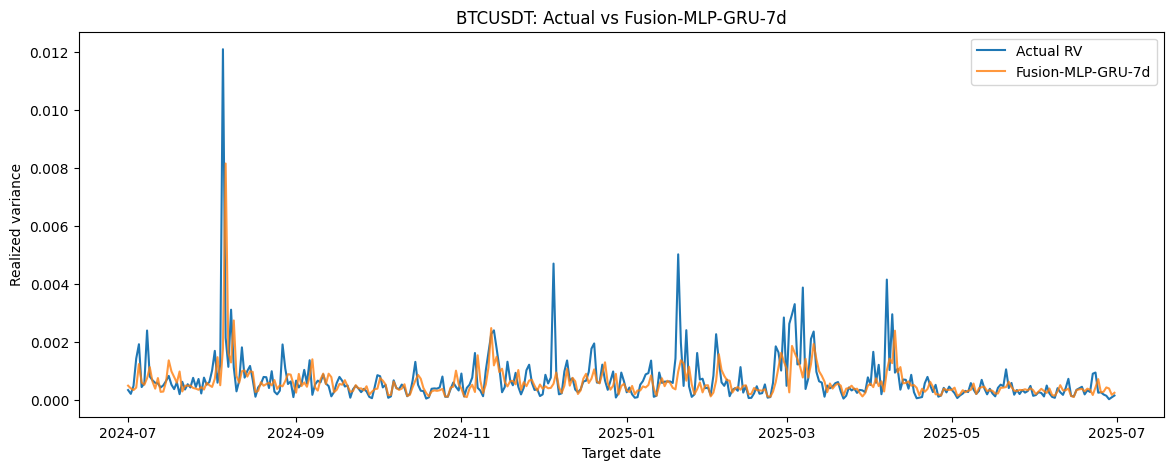

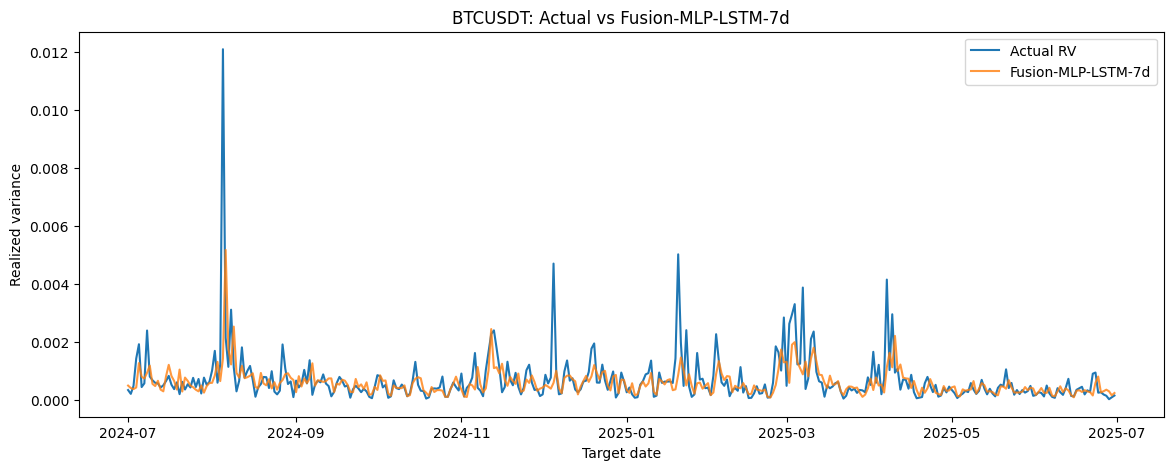

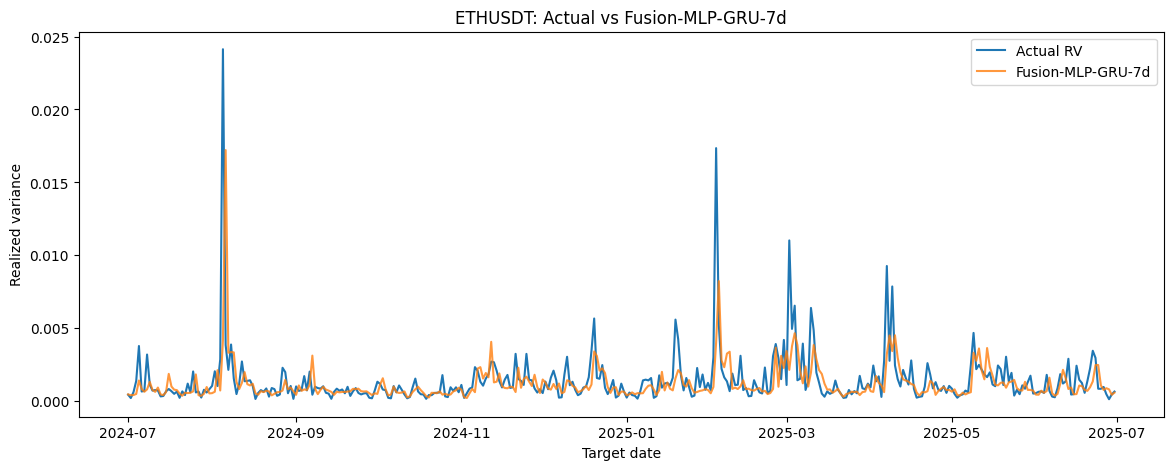

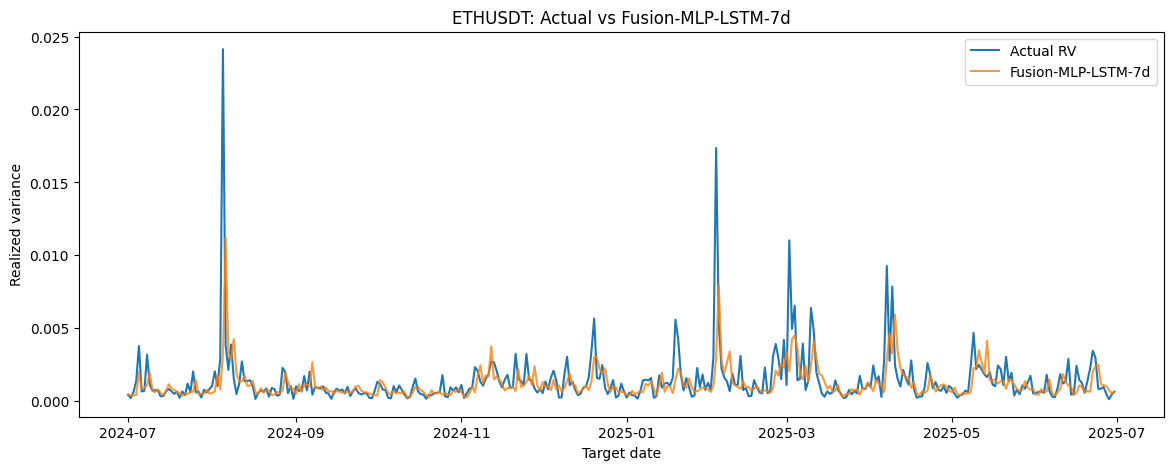

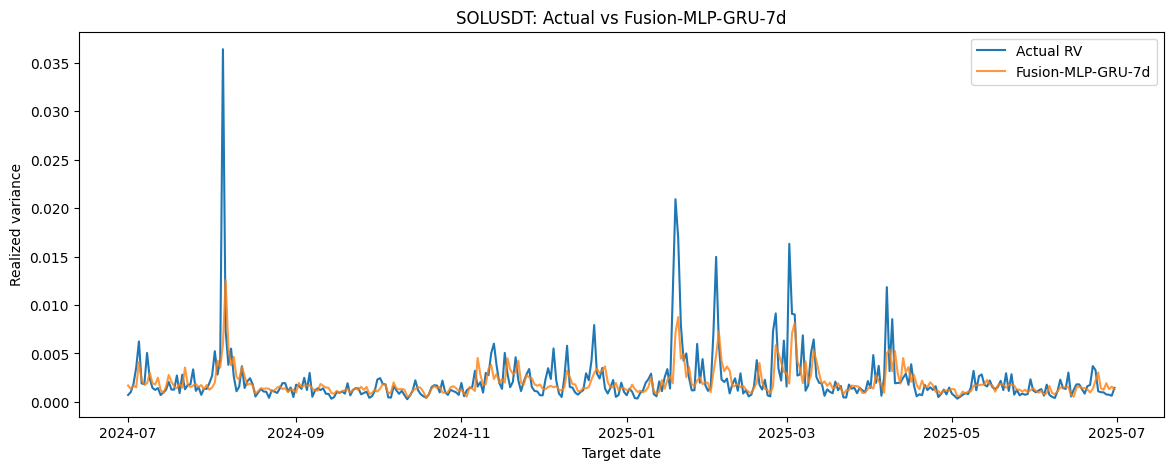

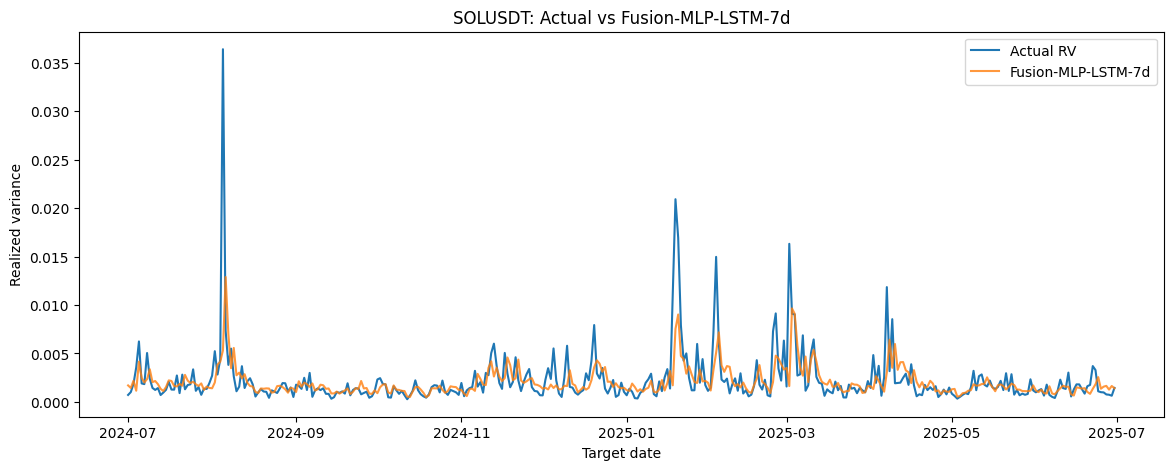

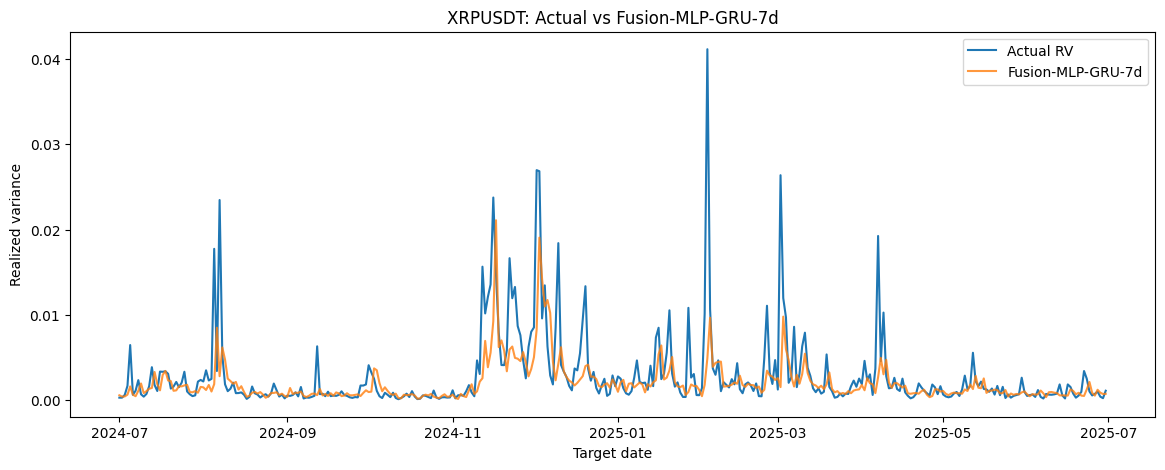

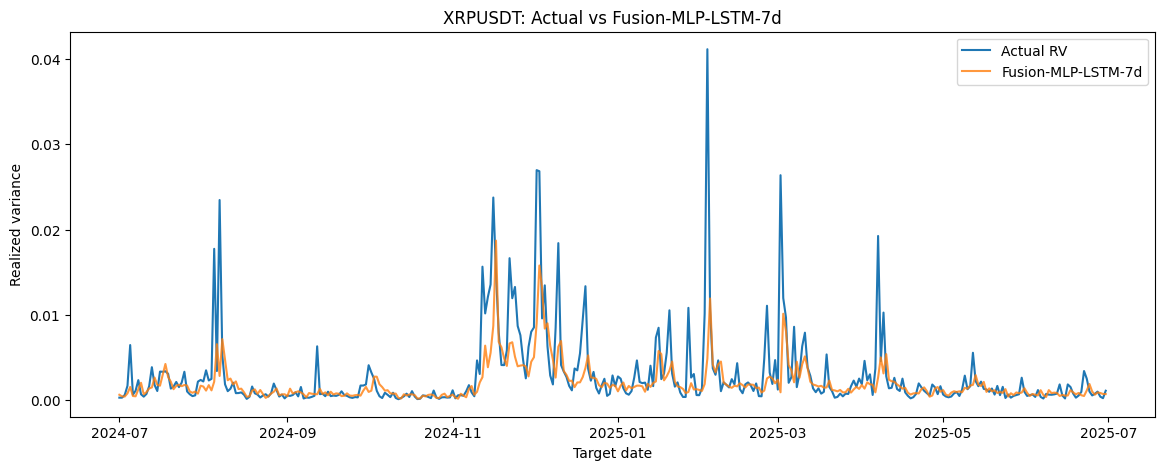

In [14]:
fusion_predictions_df = pd.concat(
    fusion_prediction_frames,
    ignore_index=True
)

for symbol in ASSETS:
    for model_name in [
        "Fusion-MLP-GRU-7d",
        "Fusion-MLP-LSTM-7d",
    ]:
        plot_df = (
            fusion_predictions_df.loc[
                fusion_predictions_df[
                    "symbol"
                ].eq(symbol)
                & fusion_predictions_df[
                    "model"
                ].eq(model_name)
            ]
            .sort_values(
                "target_date"
            )
        )

        plt.figure(
            figsize=(14, 5)
        )

        plt.plot(
            plot_df["target_date"],
            plot_df["actual_rv"],
            label="Actual RV"
        )

        plt.plot(
            plot_df["target_date"],
            plot_df["pred_rv"],
            label=model_name,
            alpha=0.8
        )

        plt.xlabel("Target date")
        plt.ylabel(
            "Realized variance"
        )
        plt.title(
            f"{symbol}: Actual vs "
            f"{model_name}"
        )
        plt.legend()
        plt.show()


## 14. Decision rule

Choose the final architecture using **validation QLIKE**, not the test period.

A fusion model should be selected only when it:

1. improves overall `ALL_ASSETS` QLIKE relative to the best standalone global model;
2. improves or remains competitive for most individual assets;
3. does not gain only by worsening peak-volatility performance;
4. shows stable training and validation loss.

The untouched test set should be evaluated only after the final architecture is frozen.
